In [1]:
#BiocManager::install("clusterProfiler", version = "3.18")
#BiocManager::install("pathview")
#BiocManager::install("enrichplot")
library(clusterProfiler)
library(enrichplot)
# we use ggplot2 to add x axis labels (ex: ridgeplot)
library(ggplot2)



clusterProfiler v4.14.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


enrichplot v1.26.1 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu. Using meshes for MeSH term enrichment and semantic
analyses. Bioinformatics. 2018, 34(21):3766-3767,
doi:10.1093/bioinformatics/bty410



In [2]:
organism = "org.Hs.eg.db"
#BiocManager::install("org.Hs.eg.db", version = "3.20")
library(organism, character.only = TRUE)

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: IRanges

Loading required package: S4Vect

In [3]:
# Reading in data
df <- read.csv("/usr/users/papantonis1/aman/rnaseq_data/ranked_gene_list.txt", sep = "\t", header = TRUE)

# Remove version numbers from ENSEMBL IDs
df$ensembl_clean <- sub("\\..*", "", df$ensembl)

# Build named vector for gene list
original_gene_list <- df$log2FC
names(original_gene_list) <- df$ensembl_clean

# Filter NAs and sort
gene_list <- na.omit(original_gene_list)
gene_list <- sort(gene_list, decreasing = TRUE)

# Check it's working
head(gene_list)

ENSG00000228205 ENSG00000254211 ENSG00000285747 ENSG00000259571 ENSG00000132437 
       6.559015        5.900297        5.782576        5.777399        5.772329 
ENSG00000187288 
       5.497158

In [4]:
str(gene_list)

 Named num [1:49321] 6.56 5.9 5.78 5.78 5.77 ...
 - attr(*, "names")= chr [1:49321] "ENSG00000228205" "ENSG00000254211" "ENSG00000285747" "ENSG00000259571" ...


In [5]:
keytypes(org.Hs.eg.db)

[1] "ACCNUM"       "ALIAS"        "ENSEMBL"      "ENSEMBLPROT"  "ENSEMBLTRANS"
 [6] "ENTREZID"     "ENZYME"       "EVIDENCE"     "EVIDENCEALL"  "GENENAME"    
[11] "GENETYPE"     "GO"           "GOALL"        "IPI"          "MAP"         
[16] "OMIM"         "ONTOLOGY"     "ONTOLOGYALL"  "PATH"         "PFAM"        
[21] "PMID"         "PROSITE"      "REFSEQ"       "SYMBOL"       "UCSCKG"      
[26] "UNIPROT"

In [6]:
library(clusterProfiler)
library(org.Hs.eg.db)

id_map <- bitr(names(gene_list),
               fromType = "ENSEMBL",
               toType = "ENTREZID",
               OrgDb = org.Hs.eg.db)

# Keep only mappable genes
gene_list_mapped <- gene_list[names(gene_list) %in% id_map$ENSEMBL]
# Map ENSEMBL to ENTREZ with gene list
id_df <- id_map[match(names(gene_list), id_map$ENSEMBL), ]
df <- data.frame(ENTREZID = id_df$ENTREZID, log2FC = gene_list)

# Remove duplicated ENTREZ IDs
df <- df[!duplicated(df$ENTREZID), ]

# Final ranked vector for GSEA
gene_list_mapped <- df$log2FC
names(gene_list_mapped) <- df$ENTREZID

# Remove NA-named entries (unmapped ENSEMBL IDs)
gene_list_mapped <- gene_list_mapped[!is.na(names(gene_list_mapped))]


# Final sanity check
str(gene_list_mapped)
anyNA(names(gene_list_mapped))  # Should return FALSE

gene_list_mapped

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(names(gene_list), fromType = "ENSEMBL", toType = "ENTREZID", :
“46.97% of input gene IDs are fail to map...”


 Named num [1:26125] 6.56 5.9 5.78 5.77 5.5 ...
 - attr(*, "names")= chr [1:26125] "440991" "101928154" "414899" "1644" ...


[1] FALSE

440991     101928154        414899          1644         63924 
 6.559015e+00  5.900297e+00  5.777399e+00  5.772329e+00  5.497158e+00 
          117         57348        286754        165904     107986742 
 5.493458e+00  5.322548e+00  5.210183e+00  5.134285e+00  5.118526e+00 
    100422862     100113397     101928917     124901813         10891 
 5.101794e+00  5.029807e+00  4.929193e+00  4.928471e+00  4.909265e+00 
       125931          7503         11254        147381     100419436 
 4.909032e+00  4.900141e+00  4.890720e+00  4.890580e+00  4.881238e+00 
          269        654412         51442           717          4633 
 4.777107e+00  4.776138e+00  4.689370e+00  4.662175e+00  4.654263e+00 
         1825          1812        200844          2864     106479669 
 4.652114e+00  4.642921e+00  4.642869e+00  4.641009e+00  4.637224e+00 
       653156          3067         51267        388719         56000 
 4.637150e+00  4.635581e+00  4.632857e+00  4.631726e+00  4.631725e+00 
    108783646         11156        339403     100500845        124599 
 4.631586e+00  4.631522e+00  4.622006e+00  4.621411e+00  4.621352e+00 
    101928336          8808        204219     101926955     106479429 
 4.611290e+00  4.609874e+00  4.608628e+00  4.607986e+00  4.607978e+00 
         4661     127379695          6097          1806     100289656 
 4.607741e+00  4.500120e+00  4.487065e+00  4.482076e+00  4.472785e+00 
    110806272        284099     100418754     106481973        391099 
 4.463581e+00  4.344021e+00  4.344021e+00  4.343839e+00  4.339860e+00 
        79150        345041          6693     100507254        391135 
 4.338448e+00  4.329362e+00  4.329163e+00  4.328502e+00  4.327970e+00 
         9118          8832     105377031     100132076     107075279 
 4.326773e+00  4.325291e+00  4.324738e+00  4.315303e+00  4.315300e+00 
       285412        387590          6375     100506409         56146 
 4.315286e+00  4.315281e+00  4.315111e+00  4.315044e+00  4.315020e+00 
       256051          5334          3026        729085         84101 
 4.314897e+00  4.307936e+00  4.305443e+00  4.304971e+00  4.304046e+00 
         3853     106479434         27098           108        285596 
 4.302863e+00  4.302550e+00  4.302211e+00  4.301776e+00  4.301450e+00 
       115361     105378934        645687         84699         25984 
 4.301051e+00  4.301012e+00  4.301012e+00  4.301012e+00  4.301005e+00 
    100505591     106480409          6035          6010         26526 
 4.288908e+00  4.288619e+00  4.287447e+00  4.287218e+00  4.287163e+00 
        84217     107075134          3036     124900224     105372799 
 4.286947e+00  4.286130e+00  4.286116e+00  4.139219e+00  4.124924e+00 
        84871     100132891         90249     106479742     105376121 
 4.118628e+00  4.110435e+00  4.110182e+00  4.110182e+00  4.109396e+00 
       164781        386597     100288801          4311          2554 
 4.099537e+00  3.928763e+00  3.928763e+00  3.928763e+00  3.928763e+00 
        51214     124902897     106480950     100420325     106480148 
 3.928763e+00  3.928763e+00  3.928763e+00  3.928763e+00  3.928690e+00 
    100129774         93650     100418720     101929268        729083 
 3.928670e+00  3.928205e+00  3.928027e+00  3.927735e+00  3.927442e+00 
        29930        283659        645939     101928264         81035 
 3.926986e+00  3.926970e+00  3.926750e+00  3.924787e+00  3.924459e+00 
       123920          8600     100126270        254910        646127 
 3.923746e+00  3.922738e+00  3.921069e+00  3.909805e+00  3.909805e+00 
         9201          2016        644246        644548          2170 
 3.909691e+00  3.909647e+00  3.909647e+00  3.909637e+00  3.909559e+00 
    100616284          3363         89832          5789     100271553 
 3.909489e+00  3.909321e+00  3.909321e+00  3.909185e+00  3.909175e+00 
       150291         81244        653140         84684        343702 
 3.909125e+00  3.908417e+00  3.906117e+00  3.905591e+00  3.905386e+00 
       400541         54570    

In [16]:
# Strip version from Ensembl IDs
ens_ids <- gsub("\\..*", "", names(gene_list))

# Map Ensembl to Gene Symbols
library(clusterProfiler)
library(org.Hs.eg.db)
symbol_map <- bitr(ens_ids, fromType = "ENSEMBL", toType = "SYMBOL", OrgDb = org.Hs.eg.db)

# Create a modular data frame with log2FC and gene symbols
gene_logfc_df <- data.frame(ENSEMBL = ens_ids, log2FC = gene_list)
gene_logfc_df <- merge(gene_logfc_df, symbol_map, by = "ENSEMBL")

# Final table: SYMBOL, ENSEMBL, log2FC
head(gene_logfc_df)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(ens_ids, fromType = "ENSEMBL", toType = "SYMBOL", OrgDb = org.Hs.eg.db):
“46.97% of input gene IDs are fail to map...”


,ENSEMBL,log2FC,SYMBOL
,<chr>,<dbl>,<chr>
1,ENSG00000000003,-0.008827647,TSPAN6
2,ENSG00000000419,-0.074333786,DPM1
3,ENSG00000000457,-0.027713822,SCYL3
4,ENSG00000000460,-0.057306352,FIRRM
5,ENSG00000000938,2.329072136,FGR
6,ENSG00000000971,-2.422586914,CFH


In [7]:
gsea_result <- gseGO(geneList = gene_list_mapped,
                     ont = "ALL",
                     keyType = "ENTREZID",
                     OrgDb = org.Hs.eg.db,
                     nPerm = 10000,
                     minGSSize = 3,
                     maxGSSize = 800,
                     pvalueCutoff = 0.05,
                     pAdjustMethod = "none",
                     verbose = TRUE)


using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysis...

Warning message in .GSEA(geneList = geneList, exponent = exponent, minGSSize = minGSSize, :
“We do not recommend using nPerm parameter incurrent and future releases”
Warning message in fgsea(pathways = geneSets, stats = geneList, nperm = nPerm, minSize = minGSSize, :
“You are trying to run fgseaSimple. It is recommended to use fgseaMultilevel. To run fgseaMultilevel, you need to remove the nperm argument in the fgsea function call.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (5.3% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



In [15]:
gsea_result

#
# Gene Set Enrichment Analysis
#
#...@organism 	 Homo sapiens 
#...@setType 	 GOALL 
#...@keytype 	 ENTREZID 
#...@geneList 	 Named num [1:26125] 6.56 5.9 5.78 5.77 5.5 ...
 - attr(*, "names")= chr [1:26125] "440991" "101928154" "414899" "1644" ...
#...nPerm 	 10000 
#...pvalues adjusted by 'none' with cutoff <0.05 
#...515 enriched terms found
'data.frame':	515 obs. of  12 variables:
 $ ONTOLOGY       : chr  "CC" "CC" "MF" "MF" ...
 $ ID             : chr  "GO:0030055" "GO:0005925" "GO:0031781" "GO:0031782" ...
 $ Description    : chr  "cell-substrate junction" "focal adhesion" "type 3 melanocortin receptor binding" "type 4 melanocortin receptor binding" ...
 $ setSize        : int  424 414 4 4 340 332 3 3 3 88 ...
 $ enrichmentScore: num  0.469 0.466 0.993 0.993 0.469 ...
 $ NES            : num  1.51 1.5 1.5 1.5 1.48 ...
 $ pvalue         : num  0.000189 0.00019 0.000193 0.000193 0.00038 ...
 $ p.adjust       : num  0.000189 0.00019 0.000193 0.000193 0.00038 ...
 $ qvalue         

Loading required package: DOSE

DOSE v4.0.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Guang-Rong Yan, Qing-Yu He. DOSE: an
R/Bioconductor package for Disease Ontology Semantic and Enrichment
analysis. Bioinformatics. 2015, 31(4):608-609



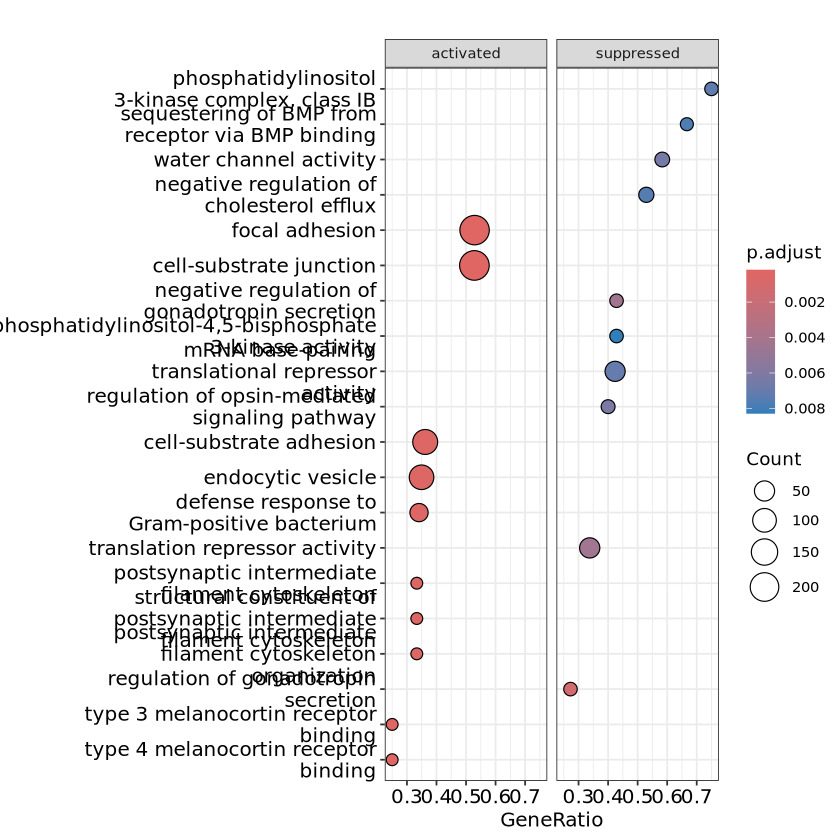

In [8]:
require(DOSE)
dotplot(gsea_result, showCategory=10, split=".sign") + facet_grid(.~.sign)

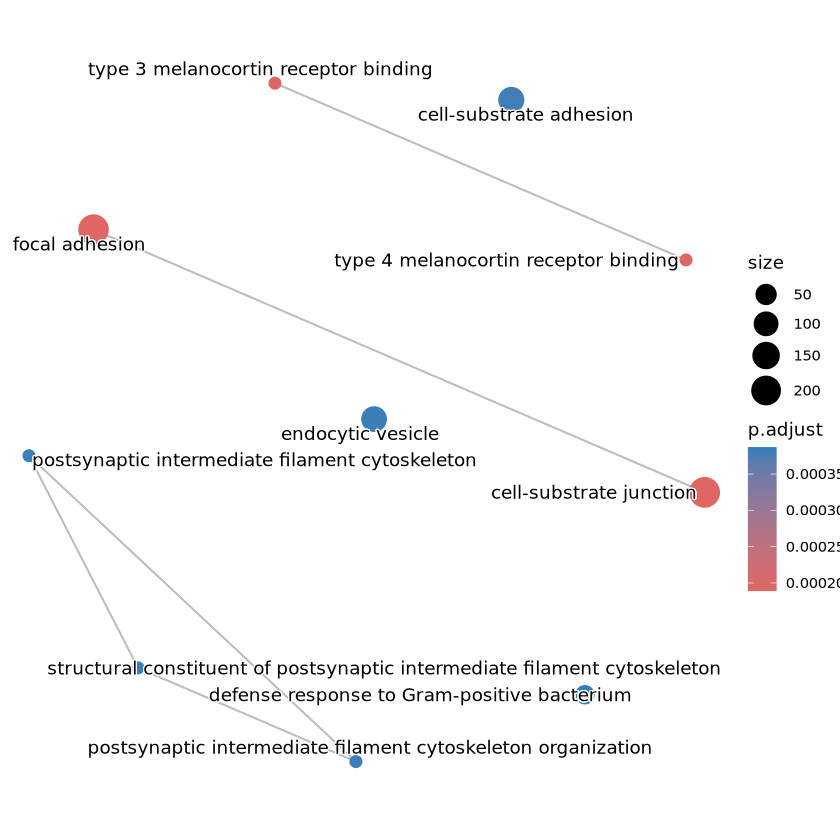

In [9]:
gsea_result <- pairwise_termsim(gsea_result)
emapplot(gsea_result, showCategory = 10)

Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


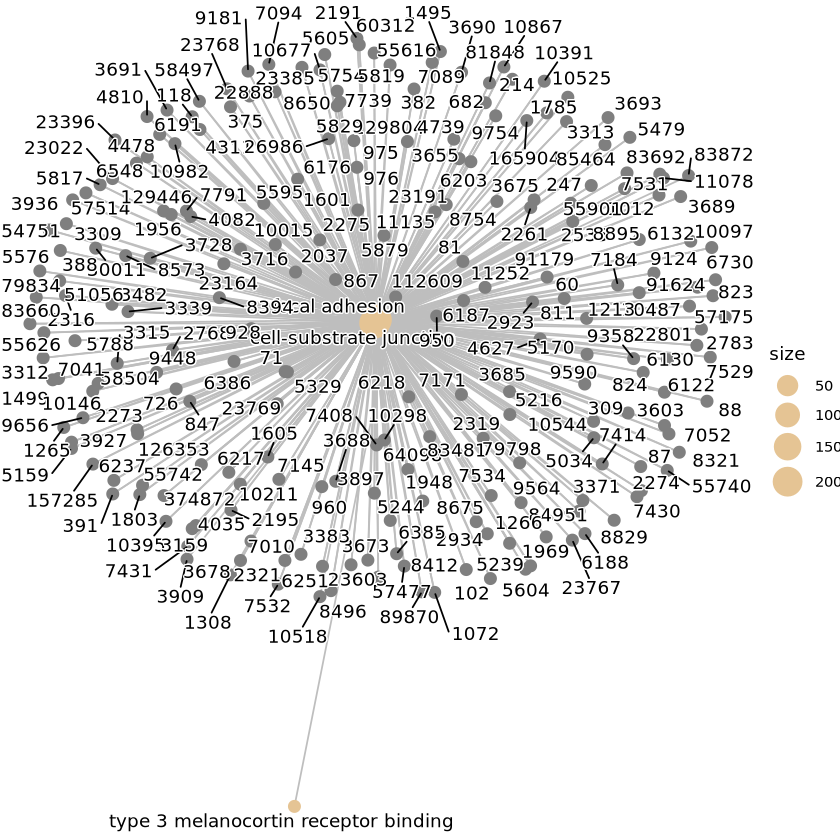

In [10]:
# categorySize can be either 'pvalue' or 'geneNum'
cnetplot(gsea_result, categorySize="pvalue", foldChange=gene_list, showCategory = 3)

Picking joint bandwidth of 0.268



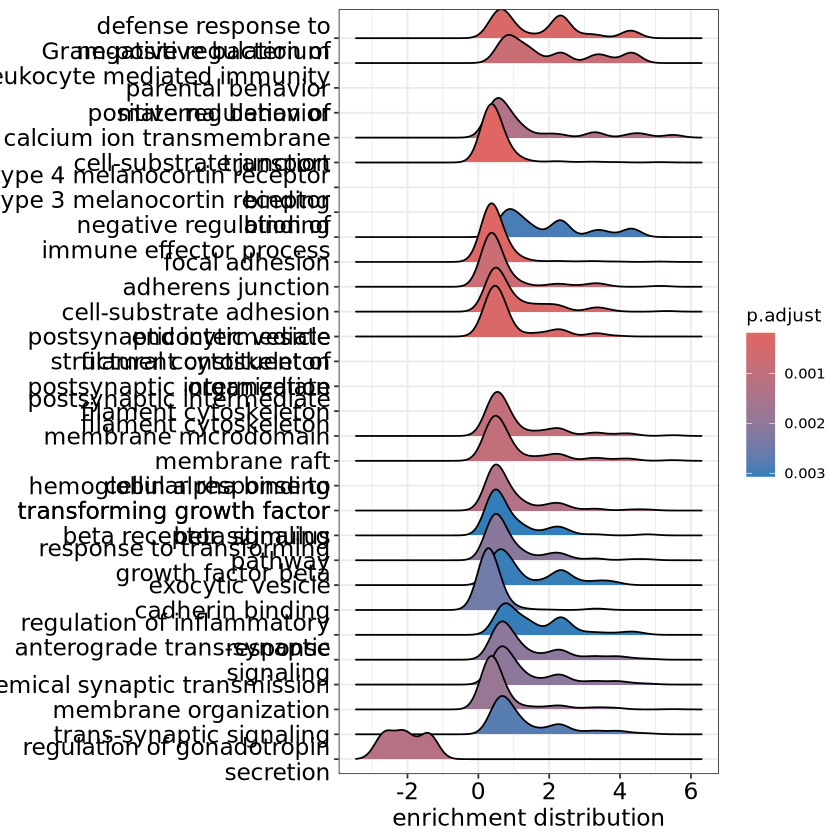

In [11]:
ridgeplot(gsea_result) + labs(x = "enrichment distribution")

In [12]:
#gsea_result@result$Description <- stringr::str_wrap(gsea_result@result$Description, width = 30)

Picking joint bandwidth of 0.243



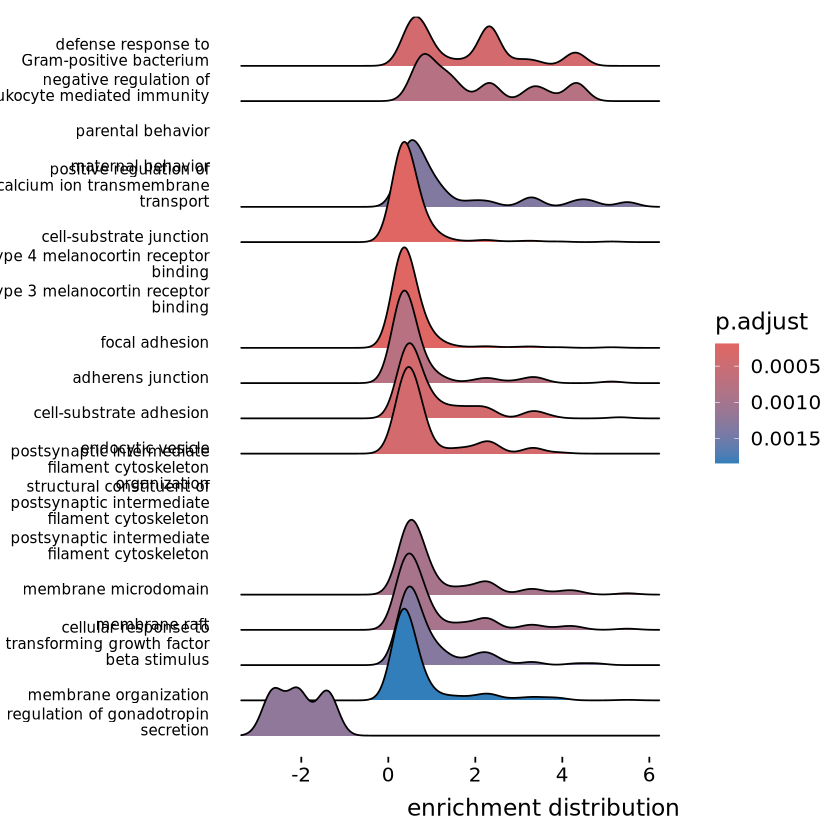

In [13]:
library(ggridges)

ridgeplot(gsea_result, showCategory = 20, fill = "p.adjust") +
  theme_ridges(grid = FALSE) +
  labs(x = "enrichment distribution") +
  theme(
    axis.text.y = element_text(size = 9),
    plot.margin = margin(10, 10, 10, 10),
    panel.spacing = unit(1.4, "lines")
  )


In [14]:
gsea_result$Description

[1] "cell-substrate junction"                                                                                                                         
  [2] "focal adhesion"                                                                                                                                  
  [3] "type 3 melanocortin receptor binding"                                                                                                            
  [4] "type 4 melanocortin receptor binding"                                                                                                            
  [5] "cell-substrate adhesion"                                                                                                                         
  [6] "endocytic vesicle"                                                                                                                               
  [7] "postsynaptic intermediate filament cytoskeleton"                                                                                                 
  [8] "structural constituent of postsynaptic intermediate filament cytoskeleton"                                                                       
  [9] "postsynaptic intermediate filament cytoskeleton organization"                                                                                    
 [10] "defense response to Gram-positive bacterium"                                                                                                     
 [11] "adherens junction"                                                                                                                               
 [12] "negative regulation of leukocyte mediated immunity"                                                                                              
 [13] "membrane raft"                                                                                                                                   
 [14] "membrane microdomain"                                                                                                                            
 [15] "regulation of gonadotropin secretion"                                                                                                            
 [16] "cellular response to transforming growth factor beta stimulus"                                                                                   
 [17] "parental behavior"                                                                                                                               
 [18] "maternal behavior"                                                                                                                               
 [19] "positive regulation of calcium ion transmembrane transport"                                                                                      
 [20] "membrane organization"                                                                                                                           
 [21] "chemical synaptic transmission"                                                                                                                  
 [22] "anterograde trans-synaptic signaling"                                                                                                            
 [23] "response to transforming growth factor beta"                                                                                                     
 [24] "cadherin binding"                                                                                                                                
 [25] "hemoglobin alpha binding"                                                                                                                        
 [26] "trans-synaptic signaling"                                                                                                                        
 [27] "negative regulati

#### Connecting back to loops (loop anchors)